# Updated Figures For Paper


Main goals:
- updated benchmark choices;
- add LSTm;
- add `M5` dataset;
- update the sparsity section


In [13]:
# Project setup
import os
import sys
from pathlib import Path
from dataclasses import dataclass


notebook_dir = Path.cwd()
project_root = notebook_dir.parent if notebook_dir.name == 'notebooks' else notebook_dir
os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f'Project root: {project_root}')


Project root: /Users/cyrilgarcia/notebooks/tsnn


In [14]:
%load_ext autoreload
%autoreload 2

import math
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LassoCV

from tsnn import utils
from tsnn.generators import generators
from tsnn.tstorch import models
from tsnn.benchmarks import benchmark_comparison, ml_benchmarks, torch_benchmarks
from tsnn.benchmarks.torch_benchmarks import MSELossWithL1Sparsity

from neuralforecast import NeuralForecast
from neuralforecast.models import TFT, TiDE, NBEATSx
from datasetsforecast.m5 import M5

plt.style.use('ggplot')

device = (
    'cuda' if torch.cuda.is_available()
    else 'mps' if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available()
    else 'cpu'
)
print('device =', device)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
device = mps


## Shared Helpers


In [15]:
def causal_mask(b, h, q_idx, kv_idx):
    return q_idx >= kv_idx


def build_attention_mask(mask_fn, seq_len, device='cpu'):
    q_idx = torch.arange(seq_len, device=device)
    kv_idx = torch.arange(seq_len, device=device)
    b = torch.zeros(1, device=device)
    h = torch.zeros(1, device=device)
    return mask_fn(b, h, q_idx[:, None], kv_idx[None, :])


def _default_corr_split(n_f):
    if n_f >= 10:
        half_n_f = int(n_f / 2)
        return [1 / np.sqrt(half_n_f)] * half_n_f + [0] * half_n_f
    return [1 / np.sqrt(n_f)] * n_f




SYNTH_N_TS = 10
SYNTH_N_F = 5
TCTC_NHEAD = 1
TCTC_DROPOUT = 0.0
TCTC_VAL_PCT = 0.2
TCTC_OPTIMIZER_KWARGS = dict(lr=1e-3, betas=(0.9, 0.995), weight_decay=1e-4)


def tctc_model_kwargs(n_ts, n_f, dropout=TCTC_DROPOUT, sparsify=None, roll_y=True):
    return dict(
        nhead=TCTC_NHEAD,
        dropout=dropout,
        d_model=n_ts * n_f,
        dim_feedforward=n_ts * n_f * 2,
        sparsify=sparsify,
        roll_y=roll_y,
        embeddings='both',
    )


def make_tctc_optimizer(model):
    return torch.optim.AdamW(model.parameters(), **TCTC_OPTIMIZER_KWARGS)

def benchmark_cases(rho=0.2):
    return [
        {'case': f'TS_shift_rho_{rho:.2f}', 'effect': 'TS_shift', 'rho': rho},
        {'case': f'CS_shift_rho_{rho:.2f}', 'effect': 'CS_shift', 'rho': rho},
        {'case': f'TSCS_shift_rho_{rho:.2f}', 'effect': 'TSCS_shift', 'rho': rho},
        {'case': f'fea_cond_rho_{rho:.2f}', 'effect': 'fea_cond', 'rho': rho},
    ]


def generate_project_generator_dataset(
    effect='TSCS_shift',
    T=4000,
    n_ts=10,
    n_f=5,
    rho=0.1,
    random_ts_shift=1,
    seed=0,
    shuffle_cs=True,
):
    np.random.seed(seed)
    torch.manual_seed(seed)

    z = generators.Generator(T, n_ts, n_f)
    z.generate_dataset_gr_simple(
        global_corr=rho,
        correl_split_by_fea=_default_corr_split(n_f),
        list_type_effects=[effect] * n_f,
        list_type_interaction=['cond'],
        random_ts_shift=random_ts_shift,
        shuffle_cs=shuffle_cs,
    )
    return z.X, z.y, z.ys['optimal'], z


def build_loaders_from_tensors(
    X,
    y,
    n_rolling=10,
    batch_size=256,
    train_pct=0.625,
    train_shuffle=False,
    test_shuffle=False,
    roll_y=False,
):
    dataset = utils.TorchDatasetRolling(X, y, n=n_rolling, roll_y=roll_y)
    train_size = int(train_pct * len(dataset))
    train_data = torch.utils.data.Subset(dataset, range(train_size))
    test_data = torch.utils.data.Subset(dataset, range(train_size, len(dataset)))
    collate_fn = lambda batch: utils.collate_pad_beginning(batch, max_len=n_rolling)
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=train_shuffle, collate_fn=collate_fn)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=test_shuffle, collate_fn=collate_fn)
    return train_loader, test_loader


def corr_from_arrays(pred, target):
    pred = np.asarray(pred).reshape(-1)
    target = np.asarray(target).reshape(-1)
    finite_mask = np.isfinite(pred) & np.isfinite(target)
    if finite_mask.sum() < 2:
        return np.nan
    pred = pred[finite_mask]
    target = target[finite_mask]
    if np.std(pred) == 0 or np.std(target) == 0:
        return 0.0
    return np.corrcoef(pred, target)[0, 1]


def mse_from_arrays(pred, target):
    pred = np.asarray(pred).reshape(-1)
    target = np.asarray(target).reshape(-1)
    finite_mask = np.isfinite(pred) & np.isfinite(target)
    if finite_mask.sum() == 0:
        return np.nan
    return float(np.mean((pred[finite_mask] - target[finite_mask]) ** 2))


def mae_from_arrays(pred, target):
    pred = np.asarray(pred).reshape(-1)
    target = np.asarray(target).reshape(-1)
    finite_mask = np.isfinite(pred) & np.isfinite(target)
    if finite_mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs(pred[finite_mask] - target[finite_mask])))


def build_padded_rolling_windows(X, n_rolling):
    X_np = X.detach().cpu().numpy() if torch.is_tensor(X) else np.asarray(X)
    T, n_ts, n_f = X_np.shape
    windows = np.zeros((T, n_rolling, n_ts, n_f), dtype=np.float32)
    for t in range(T):
        start = max(0, t - n_rolling + 1)
        window = X_np[start:t + 1]
        windows[t, -window.shape[0]:] = window
    return windows


def corr_to_optimal(model_wrapper, dataloader, y_opt):
    preds = []
    model_wrapper.model.eval()
    eval_loader = DataLoader(
        dataloader.dataset,
        batch_size=dataloader.batch_size,
        shuffle=False,
        collate_fn=dataloader.collate_fn,
    )

    with torch.no_grad():
        for batch in eval_loader:
            if len(batch) == 3:
                X_batch, _, pad_mask = batch
                pred = model_wrapper.model(X_batch.to(device), pad_mask=pad_mask.to(device)).detach().cpu()
            else:
                X_batch, _ = batch
                pred = model_wrapper.model(X_batch.to(device)).detach().cpu()
            if pred.ndim == 3:
                pred = pred[:, -1, :]
            preds.append(pred.flatten())

    preds = torch.cat(preds).numpy()
    idx = dataloader.dataset.indices
    target = y_opt[idx].reshape(-1).numpy()
    return corr_from_arrays(preds, target)


def loader_metrics_actual(model_wrapper, dataloader):
    preds = []
    targets = []
    model_wrapper.model.eval()
    eval_loader = DataLoader(
        dataloader.dataset,
        batch_size=dataloader.batch_size,
        shuffle=False,
        collate_fn=dataloader.collate_fn,
    )

    with torch.no_grad():
        for batch in eval_loader:
            if len(batch) == 3:
                X_batch, y_batch, pad_mask = batch
                pred = model_wrapper.model(X_batch.to(device), pad_mask=pad_mask.to(device)).detach().cpu()
            else:
                X_batch, y_batch = batch
                pred = model_wrapper.model(X_batch.to(device)).detach().cpu()
            if pred.ndim == 3:
                pred = pred[:, -1, :]
            if y_batch.ndim == 3:
                y_batch = y_batch[:, -1, :]
            preds.append(pred.numpy())
            targets.append(y_batch.numpy())

    pred_arr = np.concatenate(preds, axis=0)
    target_arr = np.concatenate(targets, axis=0)
    return {
        'corr': corr_from_arrays(pred_arr, target_arr),
        'mse': mse_from_arrays(pred_arr, target_arr),
    }




## NeuralForecast Helpers

These helpers keep the evaluation protocol close to the synthetic generator task: one-step prediction from historical exogenous inputs, then correlation against the optimal target when available.


In [16]:
def build_neuralforecast_xy_df(X, y):
    X_np = X.detach().cpu().numpy() if torch.is_tensor(X) else np.asarray(X)
    y_np = y.detach().cpu().numpy() if torch.is_tensor(y) else np.asarray(y)
    T, n_ts, n_f = X_np.shape
    rows = []
    for s in range(n_ts):
        for t in range(T):
            row = {'unique_id': str(s), 'ds': int(t), 'y': float(y_np[t, s])}
            for f in range(n_f):
                row[f'x{f}'] = float(X_np[t, s, f])
            rows.append(row)
    return pd.DataFrame(rows)


def default_nf_trainer_kwargs():
    return dict(
        accelerator='auto',
        devices=1,
        enable_progress_bar=False,
        enable_model_summary=False,
        logger=False,
        log_every_n_steps=10**9,
    )


def quiet_nf_call(fn, *args, **kwargs):
    import contextlib
    import io
    import warnings

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            return fn(*args, **kwargs)


def neuralforecast_futr_exog_metrics(model_builder, X, y, y_opt, train_pct=0.625, train_eval_steps=100, test_eval_steps=None, val_pct=0.2):
    X_np = X.detach().cpu().numpy() if torch.is_tensor(X) else np.asarray(X)
    y_np = y.detach().cpu().numpy() if torch.is_tensor(y) else np.asarray(y)
    y_opt_np = y_opt.detach().cpu().numpy() if torch.is_tensor(y_opt) else np.asarray(y_opt)
    T, n_ts, n_f = X_np.shape
    train_cut = int(T * train_pct)
    full_df = build_neuralforecast_xy_df(X, y)
    futr_exog_list = [f'x{f}' for f in range(n_f)]

    train_df = full_df[full_df['ds'] < train_cut].copy()
    val_size = max(1, int(train_cut * val_pct)) if val_pct and val_pct > 0 else 0
    model = model_builder(n_series=n_ts, futr_exog_list=futr_exog_list)
    nf = NeuralForecast(models=[model], freq=1)
    quiet_nf_call(nf.fit, train_df, val_size=val_size)

    def rollout(start_t, end_t):
        pred_steps = []
        futr_cols = ['unique_id', 'ds'] + futr_exog_list
        for t in range(start_t, end_t):
            hist_df = full_df[full_df['ds'] < t].copy()
            futr_df = full_df.loc[full_df['ds'] == t, futr_cols].copy()
            pred_t = quiet_nf_call(nf.predict, df=hist_df, futr_df=futr_df)
            model_col = [c for c in pred_t.columns if c not in ['unique_id', 'ds']][0]
            pred_t = pred_t.sort_values(['ds', 'unique_id'])
            pred_steps.append(pred_t[model_col].to_numpy())
        pred_values = np.stack(pred_steps, axis=0)
        return pred_values

    warmup = max(n_f, 10)
    train_start = min(train_cut - 1, warmup)
    train_end = min(train_cut, train_start + train_eval_steps)
    test_start = train_cut
    test_end = T if test_eval_steps is None else min(T, test_start + test_eval_steps)

    train_pred = rollout(train_start, train_end)
    test_pred = rollout(test_start, test_end)

    return {
        'train_corr_optimal': corr_from_arrays(train_pred, y_opt_np[train_start:train_end]),
        'test_corr_optimal': corr_from_arrays(test_pred, y_opt_np[test_start:test_end]),
        'train_corr_actual': corr_from_arrays(train_pred, y_np[train_start:train_end]),
        'test_corr_actual': corr_from_arrays(test_pred, y_np[test_start:test_end]),
        'train_mse_actual': mse_from_arrays(train_pred, y_np[train_start:train_end]),
        'test_mse_actual': mse_from_arrays(test_pred, y_np[test_start:test_end]),
    }



## Revised Synthetic Benchmark


In [17]:
def run_revised_synthetic_benchmark(
    T=4000,
    n_ts=SYNTH_N_TS,
    n_f=SYNTH_N_F,
    n_rolling=10,
    batch_size=256,
    seed=0,
    rho=0.2,
    torch_epochs=100,
    nf_test_eval_steps=300,
    shuffle_cs=True,
):
    np.random.seed(seed)
    torch.manual_seed(seed)

    cases = benchmark_cases(rho=rho)
    mask_c = build_attention_mask(causal_mask, n_rolling, device=device)
    results = []

    torch_model_builders = {
        'TCTC': lambda: models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC',
            **tctc_model_kwargs(n_ts, n_f, roll_y=True),
        ).to(device),
        'GlobalLSTM': lambda: models.GlobalLSTM(
            n_ts=n_ts, n_f=n_f, n_rolling=n_rolling,
            hidden_dim=128, num_layers=2, dropout=0.1,
        ).to(device),
    }

    nf_specs = [
        ('TFT', lambda n_series, futr_exog_list: TFT(
            h=1, input_size=n_rolling, futr_exog_list=futr_exog_list,
            hidden_size=64, n_head=4, dropout=0.1,
            max_steps=300, val_check_steps=50, learning_rate=1e-3,
            scaler_type='standard', random_seed=seed,
            **default_nf_trainer_kwargs(),
        )),
        ('TiDE', lambda n_series, futr_exog_list: TiDE(
            h=1, input_size=n_rolling, futr_exog_list=futr_exog_list,
            exclude_insample_y=False, hidden_size=256, dropout=0.1,
            max_steps=300, val_check_steps=50, learning_rate=1e-3,
            scaler_type='standard', random_seed=seed,
            **default_nf_trainer_kwargs(),
        )),
        ('NBEATSx', lambda n_series, futr_exog_list: NBEATSx(
            h=1, input_size=n_rolling, futr_exog_list=futr_exog_list,
            exclude_insample_y=False,
            stack_types=['identity', 'identity', 'identity'],
            mlp_units=[[256, 256], [256, 256], [256, 256]],
            max_steps=300, val_check_steps=50, learning_rate=1e-3,
            scaler_type='standard', random_seed=seed,
            **default_nf_trainer_kwargs(),
        )),
    ]

    for case in cases:
        X, y, y_opt, _ = generate_project_generator_dataset(
            effect=case['effect'], T=T, n_ts=n_ts, n_f=n_f, rho=case['rho'],
            random_ts_shift=1, seed=seed, shuffle_cs=shuffle_cs,
        )

        rolling_train_loader, rolling_test_loader = build_loaders_from_tensors(
            X, y, n_rolling=n_rolling, batch_size=batch_size,
            train_shuffle=False, test_shuffle=False, roll_y=False,
        )
        tctc_train_loader, tctc_test_loader = build_loaders_from_tensors(
            X, y, n_rolling=n_rolling, batch_size=batch_size,
            train_shuffle=False, test_shuffle=False, roll_y=True,
        )

        y_np = y.detach().cpu().numpy()
        y_opt_np = y_opt.detach().cpu().numpy()
        train_cut = int(T * 0.625)
        for model_name, build_model in torch_model_builders.items():
            model = build_model()
            model_train_loader = tctc_train_loader if model_name == 'TCTC' else rolling_train_loader
            model_test_loader = tctc_test_loader if model_name == 'TCTC' else rolling_test_loader
            optimizer = make_tctc_optimizer(model) if model_name == 'TCTC' else torch.optim.AdamW(model.parameters(), lr=0.001)
            wrapper = torch_benchmarks.TorchWrapper(
                model,
                optimizer=optimizer,
                loss_fn=nn.MSELoss(),
                device=device,
            )
            fit_kwargs = dict(
                epochs=torch_epochs,
                plot=False,
                verbose=1,
                val_pct=TCTC_VAL_PCT,
                early_stopping_metric='corr',
                val_warmup_epochs=5,
            )
            wrapper.fit(model_train_loader, model_test_loader, **fit_kwargs)
            train_metrics = loader_metrics_actual(wrapper, model_train_loader)
            test_metrics = loader_metrics_actual(wrapper, model_test_loader)
            results.append({
                'case': case['case'],
                'effect': case['effect'],
                'rho': case['rho'],
                'model': model_name,
                'train_corr_optimal': corr_to_optimal(wrapper, model_train_loader, y_opt),
                'test_corr_optimal': corr_to_optimal(wrapper, model_test_loader, y_opt),
                'train_corr_actual': train_metrics['corr'],
                'test_corr_actual': test_metrics['corr'],
                'train_mse_actual': train_metrics['mse'],
                'test_mse_actual': test_metrics['mse'],
            })

        for model_name, model_builder in nf_specs:
            nf_metrics = neuralforecast_futr_exog_metrics(
                model_builder=model_builder,
                X=X,
                y=y,
                y_opt=y_opt,
                train_pct=0.625,
                test_eval_steps=nf_test_eval_steps,
                val_pct=TCTC_VAL_PCT,
            )
            results.append({
                'case': case['case'],
                'effect': case['effect'],
                'rho': case['rho'],
                'model': model_name,
                **nf_metrics,
            })

    return pd.DataFrame(results).sort_values(['case', 'model']).reset_index(drop=True)


def display_synthetic_summary(df, metric='test_corr_optimal'):
    return (
        df.pivot_table(index='effect', columns='model', values=metric, aggfunc='mean')
          .style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1)
          .format(precision=3)
    )



In [18]:
synthetic_cmp_params = {
    'T': 4000,
    'n_ts': 10,
    'n_f': 5,
    'n_rolling': 10,
    'rho': 0.2,
    'seed': 0,
    'batch_size': 256,
    'torch_epochs': 100,
    'nf_test_eval_steps': 300,
    'shuffle_cs': False,
}

synthetic_results_rho_02 = run_revised_synthetic_benchmark(**synthetic_cmp_params)
display(synthetic_results_rho_02)
display(display_synthetic_summary(synthetic_results_rho_02, metric='test_corr_optimal'))


100%|██████████| 100/100 [00:30<00:00,  3.28it/s, train_corr=0.9289, train_loss=0.1365, test_corr=0.0296, test_loss=1.5854, val_corr=0.0206, val_loss=1.5917, lr=1.00e-03]
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer.fit` stopped: `max_steps=300` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 0
/Users/cyrilgarcia/miniconda3/envs/cyril10/lib/python3.10/site-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element te

,case,effect,rho,model,train_corr_optimal,test_corr_optimal,train_corr_actual,test_corr_actual,train_mse_actual,test_mse_actual
0,CS_shift_rho_0.20,CS_shift,0.2,GlobalLSTM,0.311214,0.360902,0.667931,0.066389,0.554534,1.321965
1,CS_shift_rho_0.20,CS_shift,0.2,NBEATSx,0.111711,0.033880,0.743680,0.004780,0.434957,1.464755
2,CS_shift_rho_0.20,CS_shift,0.2,TCTC,0.918019,0.917117,0.205076,0.189417,0.957498,0.962458
3,CS_shift_rho_0.20,CS_shift,0.2,TFT,-0.030584,-0.006909,-0.003547,-0.001798,1.093742,1.114878
4,CS_shift_rho_0.20,CS_shift,0.2,TiDE,-0.068769,-0.015360,-0.060783,0.000871,1.094576,1.085700
5,TSCS_shift_rho_0.20,TSCS_shift,0.2,GlobalLSTM,0.197685,0.226629,0.586284,0.038726,0.659071,1.277482
6,TSCS_shift_rho_0.20,TSCS_shift,0.2,NBEATSx,0.207574,-0.023112,0.751012,-0.012006,0.444763,1.432844
7,TSCS_shift_rho_0.20,TSCS_shift,0.2,TCTC,0.507464,0.496889,0.302018,0.090530,0.912615,1.044410
8,TSCS_shift_rho_0.20,TSCS_shift,0.2,TFT,-0.034998,-0.006085,0.041966,-0.005379,1.103399,1.124949
9,TSCS_shift_rho_0.20,TSCS_shift,0.2,TiDE,-0.065854,-0.011151,-0.058112,-0.002123,1.131053,1.081636


model,GlobalLSTM,NBEATSx,TCTC,TFT,TiDE
effect,,,,,
CS_shift,0.361,0.034,0.917,-0.007,-0.015
TSCS_shift,0.227,-0.023,0.497,-0.006,-0.011
TS_shift,0.239,0.283,0.943,0.431,0.001
fea_cond,0.009,0.167,0.796,0.297,0.018


In [19]:
synthetic_cmp_params_low_rho = {
    **synthetic_cmp_params,
    'torch_epochs': 150,
    'rho': 0.1,
}

synthetic_results_rho_005 = run_revised_synthetic_benchmark(**synthetic_cmp_params_low_rho)
display(synthetic_results_rho_005)
display(display_synthetic_summary(synthetic_results_rho_005, metric='test_corr_optimal'))


100%|██████████| 150/150 [00:43<00:00,  3.49it/s, train_corr=0.9537, train_loss=0.0903, test_corr=0.0030, test_loss=1.6135, val_corr=-0.0263, val_loss=1.6753, lr=1.00e-03]
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer.fit` stopped: `max_steps=300` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 0
/Users/cyrilgarcia/miniconda3/envs/cyril10/lib/python3.10/site-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element t

,case,effect,rho,model,train_corr_optimal,test_corr_optimal,train_corr_actual,test_corr_actual,train_mse_actual,test_mse_actual
0,CS_shift_rho_0.10,CS_shift,0.1,GlobalLSTM,0.127173,0.130676,0.771900,0.008906,0.411172,1.585173
1,CS_shift_rho_0.10,CS_shift,0.1,NBEATSx,0.027237,0.012092,0.767689,0.006593,0.406805,1.450209
2,CS_shift_rho_0.10,CS_shift,0.1,TCTC,0.665157,0.669040,0.131026,0.072844,0.983737,0.995140
3,CS_shift_rho_0.10,CS_shift,0.1,TFT,-0.020829,0.001745,0.045375,-0.006891,1.066789,1.123014
4,CS_shift_rho_0.10,CS_shift,0.1,TiDE,-0.062447,-0.012679,-0.052085,0.001381,1.100691,1.082292
5,TSCS_shift_rho_0.10,TSCS_shift,0.1,GlobalLSTM,0.110291,0.135895,0.381199,0.006219,0.862804,1.141140
6,TSCS_shift_rho_0.10,TSCS_shift,0.1,NBEATSx,0.165682,-0.031867,0.760559,-0.013234,0.422934,1.446963
7,TSCS_shift_rho_0.10,TSCS_shift,0.1,TCTC,0.106056,0.080453,0.563745,0.007539,0.694550,1.420666
8,TSCS_shift_rho_0.10,TSCS_shift,0.1,TFT,-0.042393,-0.009585,0.025777,0.016020,1.095955,1.092835
9,TSCS_shift_rho_0.10,TSCS_shift,0.1,TiDE,-0.058938,-0.008381,-0.051105,-0.000217,1.118957,1.080164


model,GlobalLSTM,NBEATSx,TCTC,TFT,TiDE
effect,,,,,
CS_shift,0.131,0.012,0.669,0.002,-0.013
TSCS_shift,0.136,-0.032,0.080,-0.010,-0.008
TS_shift,0.118,0.138,0.754,0.204,0.004
fea_cond,0.007,0.092,0.652,0.178,0.021


In [20]:
synthetic_cmp_params_low_rho = {
    **synthetic_cmp_params,
    'torch_epochs': 200,
    'rho': 0.05,
}

synthetic_results_rho_005 = run_revised_synthetic_benchmark(**synthetic_cmp_params_low_rho)
display(synthetic_results_rho_005)
display(display_synthetic_summary(synthetic_results_rho_005, metric='test_corr_optimal'))


100%|██████████| 200/200 [00:56<00:00,  3.53it/s, train_corr=0.9624, train_loss=0.0738, test_corr=0.0129, test_loss=1.5860, val_corr=-0.0368, val_loss=1.6882, lr=1.00e-03]
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer.fit` stopped: `max_steps=300` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 0
/Users/cyrilgarcia/miniconda3/envs/cyril10/lib/python3.10/site-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element t

,case,effect,rho,model,train_corr_optimal,test_corr_optimal,train_corr_actual,test_corr_actual,train_mse_actual,test_mse_actual
0,CS_shift_rho_0.05,CS_shift,0.05,GlobalLSTM,0.068095,0.078891,0.329763,0.011067,0.892189,1.081031
1,CS_shift_rho_0.05,CS_shift,0.05,NBEATSx,-0.013956,0.019400,0.760532,0.000411,0.440256,1.454776
2,CS_shift_rho_0.05,CS_shift,0.05,TCTC,0.045259,0.035190,0.614904,0.001490,0.643589,1.580870
3,CS_shift_rho_0.05,CS_shift,0.05,TFT,-0.041877,-0.006071,0.020817,0.008659,1.082344,1.102590
4,CS_shift_rho_0.05,CS_shift,0.05,TiDE,-0.059300,-0.011293,-0.048043,0.001348,1.104341,1.080941
5,TSCS_shift_rho_0.05,TSCS_shift,0.05,GlobalLSTM,0.058032,0.071931,0.378950,0.010439,0.858580,1.114911
6,TSCS_shift_rho_0.05,TSCS_shift,0.05,NBEATSx,0.112961,-0.029798,0.733125,-0.007668,0.466292,1.443084
7,TSCS_shift_rho_0.05,TSCS_shift,0.05,TCTC,-0.011224,0.003358,0.021746,0.000331,1.002140,0.996411
8,TSCS_shift_rho_0.05,TSCS_shift,0.05,TFT,-0.016631,-0.010272,0.019704,-0.012808,1.094359,1.114174
9,TSCS_shift_rho_0.05,TSCS_shift,0.05,TiDE,-0.056423,-0.006993,-0.047457,0.000369,1.112843,1.079707


model,GlobalLSTM,NBEATSx,TCTC,TFT,TiDE
effect,,,,,
CS_shift,0.079,0.019,0.035,-0.006,-0.011
TSCS_shift,0.072,-0.030,0.003,-0.010,-0.007
TS_shift,0.053,0.053,0.053,0.095,0.005
fea_cond,0.003,0.027,0.414,0.092,0.023


## Real-World Dataset Comparison: M5


In [21]:
m5_dir = Path('data')
m5_dir.mkdir(parents=True, exist_ok=True)

# Uncomment if the dataset is not already present locally.
# M5.download(directory=str(m5_dir))
Y_df, X_df, S_df = M5.load(directory=str(m5_dir))


In [22]:
def build_m5_subset_tensors(Y_df, X_df, S_df, store_ids=None, dept_id='FOODS_1', top_n_series=64, train_pct=0.7):
    if store_ids is None:
        store_ids = ['CA_1', 'CA_2', 'CA_3', 'CA_4']

    subset_static = S_df[(S_df['store_id'].isin(store_ids)) & (S_df['dept_id'] == dept_id)].copy()
    subset_ids = subset_static['unique_id'].tolist()

    subset_y = Y_df[Y_df['unique_id'].isin(subset_ids)].copy()
    top_ids = (
        subset_y.groupby('unique_id', as_index=False)['y']
        .sum()
        .sort_values('y', ascending=False)
        .head(top_n_series)['unique_id']
        .tolist()
    )

    subset_y = subset_y[subset_y['unique_id'].isin(top_ids)].copy()
    subset_x = X_df[X_df['unique_id'].isin(top_ids)].copy() if X_df is not None else None
    subset_s = subset_static[subset_static['unique_id'].isin(top_ids)].copy()

    merged = subset_y.copy()
    if subset_x is not None:
        merged = merged.merge(subset_x, on=['unique_id', 'ds'], how='left')
    merged = merged.merge(subset_s, on='unique_id', how='left')
    merged['ds'] = pd.to_datetime(merged['ds'])
    merged = merged.sort_values(['unique_id', 'ds'])
    merged['y'] = merged.groupby('unique_id', sort=False)['y'].diff()
    merged = merged.dropna(subset=['y']).copy()

    future_cols = ['sell_price', 'snap_CA', 'snap_TX', 'snap_WI']
    static_cols = []
    feature_cols = future_cols.copy()

    unique_ids = sorted(top_ids)
    all_dates = pd.Index(sorted(merged['ds'].unique()))
    y_panel = merged.pivot(index='ds', columns='unique_id', values='y').reindex(index=all_dates, columns=unique_ids)
    feature_panels = [
        merged.pivot(index='ds', columns='unique_id', values=col).reindex(index=all_dates, columns=unique_ids)
        for col in feature_cols
    ]

    common_index = y_panel.dropna().index
    for panel in feature_panels:
        common_index = common_index.intersection(panel.dropna().index)

    y_panel = y_panel.loc[common_index]
    feature_panels = [panel.loc[common_index] for panel in feature_panels]
    merged_balanced = merged[merged['ds'].isin(common_index) & merged['unique_id'].isin(unique_ids)].copy()
    merged_balanced = merged_balanced.sort_values(['unique_id', 'ds']).reset_index(drop=True)

    X_aligned_raw = np.stack([panel.to_numpy(dtype=np.float32) for panel in feature_panels], axis=-1)
    y_aligned_raw = y_panel.to_numpy(dtype=np.float32)

    X_aligned_raw = np.concatenate([X_aligned_raw, y_aligned_raw[..., None]], axis=-1)
    feature_cols = feature_cols + ['insample_delta_y']

    X_task_raw = X_aligned_raw[:-1]
    y_task_raw = y_aligned_raw[1:]

    train_cut = int(len(y_task_raw) * train_pct)
    X_train = X_task_raw[:train_cut]
    y_train = y_task_raw[:train_cut]

    feat_mean = X_train.mean(axis=(0, 1), keepdims=True)
    feat_std = X_train.std(axis=(0, 1), keepdims=True)
    feat_std[feat_std == 0] = 1
    targ_mean = y_train.mean(axis=0, keepdims=True)
    targ_std = y_train.std(axis=0, keepdims=True)
    targ_std[targ_std == 0] = 1

    X_task = (X_task_raw - feat_mean) / feat_std
    y_task = (y_task_raw - targ_mean) / targ_std

    nf_df = merged_balanced[['unique_id', 'ds', 'y'] + future_cols].copy()
    nf_futr_df = merged_balanced[['unique_id', 'ds'] + future_cols].copy()
    nf_static_df = (
        merged_balanced[['unique_id'] + static_cols]
        .drop_duplicates('unique_id')
        .sort_values('unique_id')
        .reset_index(drop=True)
    )

    return (
        torch.tensor(X_task),
        torch.tensor(y_task),
        {
            'store_ids': store_ids,
            'dept_id': dept_id,
            'top_n_series': len(unique_ids),
            'series_ids': unique_ids,
            'feature_cols': feature_cols,
            'future_cols': future_cols,
            'static_cols': static_cols,
            'train_pct': train_pct,
            'y_task_raw': y_task_raw,
            'target_mean': targ_mean.astype(np.float32),
            'target_std': targ_std.astype(np.float32),
            'nf_df': nf_df,
            'nf_futr_df': nf_futr_df,
            'nf_static_df': nf_static_df,
            'aligned_dates': list(common_index),
        },
    )


def inverse_standardize_panel(values, target_mean, target_std):
    arr = np.asarray(values, dtype=np.float32)
    return arr * target_std + target_mean


def m5_loader_metrics_actual(model_wrapper, dataloader, target_mean, target_std):
    preds = []
    targets = []
    model_wrapper.model.eval()
    eval_loader = DataLoader(
        dataloader.dataset,
        batch_size=dataloader.batch_size,
        shuffle=False,
        collate_fn=dataloader.collate_fn,
    )

    with torch.no_grad():
        for batch in eval_loader:
            if len(batch) == 3:
                X_batch, y_batch, pad_mask = batch
                pred = model_wrapper.model(X_batch.to(device), pad_mask=pad_mask.to(device)).detach().cpu()
            else:
                X_batch, y_batch = batch
                pred = model_wrapper.model(X_batch.to(device)).detach().cpu()
            if pred.ndim == 3:
                pred = pred[:, -1, :]
            if y_batch.ndim == 3:
                y_batch = y_batch[:, -1, :]
            preds.append(pred.numpy())
            targets.append(y_batch.numpy())

    pred_arr = np.concatenate(preds, axis=0)
    target_arr = np.concatenate(targets, axis=0)
    pred_raw = inverse_standardize_panel(pred_arr, target_mean, target_std)
    target_raw = inverse_standardize_panel(target_arr, target_mean, target_std)
    return {
        'corr': corr_from_arrays(pred_raw, target_raw),
        'mse': mse_from_arrays(pred_raw, target_raw),
        'mae': mae_from_arrays(pred_raw, target_raw),
    }


def default_nf_trainer_kwargs_local():
    return dict(
        accelerator='auto',
        devices=1,
        enable_progress_bar=False,
        enable_model_summary=False,
        logger=False,
        log_every_n_steps=10**9,
    )


def neuralforecast_native_corrs_local(model_builder, nf_df, nf_futr_df, nf_static_df, aligned_dates, task_train_cut, train_eval_steps=30, test_eval_steps=None, val_pct=0.2):
    train_last_target_ds = aligned_dates[task_train_cut]
    train_df = nf_df[nf_df['ds'] <= train_last_target_ds].copy()

    model = model_builder()
    nf = NeuralForecast(models=[model], freq='D')
    val_size = max(1, int(task_train_cut * val_pct)) if val_pct and val_pct > 0 else 0
    nf.fit(train_df, static_df=nf_static_df, val_size=val_size)

    def target_frame(ds_target):
        return (
            nf_df[nf_df['ds'] == ds_target]
            .sort_values('unique_id')[['unique_id', 'y']]
            .reset_index(drop=True)
        )

    def rollout_metrics(shift_start, shift_end):
        if shift_end <= shift_start:
            return {'corr': np.nan, 'mse': np.nan, 'mae': np.nan}
        pred_steps = []
        target_steps = []
        for k in range(shift_start, shift_end):
            ds_target = aligned_dates[k + 1]
            hist_df = nf_df[nf_df['ds'] < ds_target].copy()
            futr_step = nf_futr_df[nf_futr_df['ds'] == ds_target].copy()
            pred_t = nf.predict(df=hist_df, static_df=nf_static_df, futr_df=futr_step)
            model_col = [c for c in pred_t.columns if c not in ['unique_id', 'ds']][0]
            pred_t = pred_t.sort_values('unique_id').reset_index(drop=True)
            pred_steps.append(pred_t[model_col].to_numpy())
            target_steps.append(target_frame(ds_target)['y'].to_numpy())
        pred_values = np.stack(pred_steps, axis=0)
        target_values = np.stack(target_steps, axis=0)
        return {
            'corr': corr_from_arrays(pred_values, target_values),
            'mse': mse_from_arrays(pred_values, target_values),
            'mae': mae_from_arrays(pred_values, target_values),
        }

    task_T = len(aligned_dates) - 1
    train_start = max(0, task_train_cut - train_eval_steps)
    train_end = task_train_cut
    test_start = task_train_cut
    test_end = task_T if test_eval_steps is None else min(task_T, test_start + test_eval_steps)

    train_metrics = rollout_metrics(train_start, train_end)
    test_metrics = rollout_metrics(test_start, test_end)
    return {
        'train_corr_actual': train_metrics['corr'],
        'test_corr_actual': test_metrics['corr'],
        'train_mse_actual': train_metrics['mse'],
        'test_mse_actual': test_metrics['mse'],
        'train_mae_actual': train_metrics['mae'],
        'test_mae_actual': test_metrics['mae'],
    }


def run_m5_subset_comparison(Y_df, X_df, S_df, params):
    torch.manual_seed(params['seed'])
    np.random.seed(params['seed'])

    X_task, y_task, meta = build_m5_subset_tensors(
        Y_df, X_df, S_df,
        store_ids=params['store_ids'],
        dept_id=params['dept_id'],
        top_n_series=params['top_n_series'],
        train_pct=params['train_pct'],
    )

    n_ts = y_task.shape[1]
    n_f = X_task.shape[2]
    n_rolling = params['n_rolling']
    train_cut = int(len(X_task) * params['train_pct'])
    target_mean = meta['target_mean']
    target_std = meta['target_std']
    y_task_raw = meta['y_task_raw']
    mask_c = build_attention_mask(causal_mask, n_rolling, device=device)

    dataset = utils.TorchDatasetRolling(X_task, y_task, n=n_rolling, roll_y=False)
    train_size = int(params['train_pct'] * len(dataset))
    train_data = torch.utils.data.Subset(dataset, range(train_size))
    test_data = torch.utils.data.Subset(dataset, range(train_size, len(dataset)))
    collate_fn = lambda batch: utils.collate_pad_beginning(batch, max_len=n_rolling)
    train_loader = DataLoader(train_data, batch_size=params['batch_size'], shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(test_data, batch_size=params['batch_size'], shuffle=False, collate_fn=collate_fn)

    results = []

    var_benchmark = ml_benchmarks.GlobalVARBenchmark(
        n_lags=n_rolling,
        alpha=1.0,
    )
    var_benchmark.fit(train_loader)
    train_pred = var_benchmark.predict(train_loader).reshape(train_cut, n_ts)
    test_pred = var_benchmark.predict(test_loader).reshape(len(X_task) - train_cut, n_ts)
    train_pred_raw = inverse_standardize_panel(train_pred, target_mean, target_std)
    test_pred_raw = inverse_standardize_panel(test_pred, target_mean, target_std)
    y_train_raw = y_task_raw[:train_cut]
    y_test_raw = y_task_raw[train_cut:]
    results.append({
        'model': 'VAR',
        'train_corr_actual': corr_from_arrays(train_pred_raw, y_train_raw),
        'test_corr_actual': corr_from_arrays(test_pred_raw, y_test_raw),
        'train_mse_actual': mse_from_arrays(train_pred_raw, y_train_raw),
        'test_mse_actual': mse_from_arrays(test_pred_raw, y_test_raw),
        'train_mae_actual': mae_from_arrays(train_pred_raw, y_train_raw),
        'test_mae_actual': mae_from_arrays(test_pred_raw, y_test_raw),
    })

    torch_model_builders = {
        'GlobalLSTM': lambda: models.GlobalLSTM(
            n_ts=n_ts, n_f=n_f, n_rolling=n_rolling,
            hidden_dim=512, num_layers=4, dropout=0.1,
        ).to(device),
        'TCTC': lambda: models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC', nhead=8,
            dropout=0.1, d_model=64, dim_feedforward=256, sparsify=None,
            roll_y=False, embeddings='both',
        ).to(device),
    }

    for model_name, build_model in torch_model_builders.items():
        model = build_model()
        optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
        wrapper = torch_benchmarks.TorchWrapper(
            model,
            optimizer=optimizer,
            loss_fn=nn.MSELoss(),
            device=device,
        )
        fit_kwargs = dict(
            epochs=params['torch_epochs'],
            plot=False,
            verbose=0,
            val_pct=TCTC_VAL_PCT,
            early_stopping_metric='corr',
            val_warmup_epochs=5,
        )
        wrapper.fit(train_loader, test_loader, **fit_kwargs)
        train_metrics = m5_loader_metrics_actual(wrapper, train_loader, target_mean, target_std)
        test_metrics = m5_loader_metrics_actual(wrapper, test_loader, target_mean, target_std)
        results.append({
            'model': model_name,
            'train_corr_actual': train_metrics['corr'],
            'test_corr_actual': test_metrics['corr'],
            'train_mse_actual': train_metrics['mse'],
            'test_mse_actual': test_metrics['mse'],
            'train_mae_actual': train_metrics['mae'],
            'test_mae_actual': test_metrics['mae'],
        })

    futr_exog_list = meta['future_cols']
    stat_exog_list = meta['static_cols']
    nf_specs = [
        ('TFT', lambda: TFT(
            h=1, input_size=n_rolling, futr_exog_list=futr_exog_list, stat_exog_list=stat_exog_list,
            hidden_size=64, n_head=4, dropout=0.1,
            max_steps=params['nf_max_steps'], val_check_steps=50, learning_rate=1e-3,
            batch_size=params['nf_batch_size'], valid_batch_size=params['nf_batch_size'],
            windows_batch_size=params['nf_windows_batch_size'], inference_windows_batch_size=params['nf_inference_windows_batch_size'],
            scaler_type='standard', random_seed=params['seed'],
            **default_nf_trainer_kwargs_local(),
        )),
        ('TiDE', lambda: TiDE(
            h=1, input_size=n_rolling, futr_exog_list=futr_exog_list, stat_exog_list=stat_exog_list,
            exclude_insample_y=False, hidden_size=256, dropout=0.1,
            max_steps=params['nf_max_steps'], val_check_steps=50, learning_rate=1e-3,
            batch_size=params['nf_batch_size'], valid_batch_size=params['nf_batch_size'],
            windows_batch_size=params['nf_windows_batch_size'], inference_windows_batch_size=params['nf_inference_windows_batch_size'],
            scaler_type='standard', random_seed=params['seed'],
            **default_nf_trainer_kwargs_local(),
        )),
        ('NBEATSx', lambda: NBEATSx(
            h=1, input_size=n_rolling, futr_exog_list=futr_exog_list, stat_exog_list=stat_exog_list,
            exclude_insample_y=False,
            stack_types=['identity', 'identity', 'identity'],
            mlp_units=[[256, 256], [256, 256], [256, 256]],
            max_steps=params['nf_max_steps'], val_check_steps=50, learning_rate=1e-3,
            batch_size=params['nf_batch_size'], valid_batch_size=params['nf_batch_size'],
            windows_batch_size=params['nf_windows_batch_size'], inference_windows_batch_size=params['nf_inference_windows_batch_size'],
            scaler_type='standard', random_seed=params['seed'],
            **default_nf_trainer_kwargs_local(),
        )),
    ]

    for model_name, model_builder in nf_specs:
        nf_metrics = neuralforecast_native_corrs_local(
            model_builder=model_builder,
            nf_df=meta['nf_df'],
            nf_futr_df=meta['nf_futr_df'],
            nf_static_df=meta['nf_static_df'],
            aligned_dates=meta['aligned_dates'],
            task_train_cut=train_cut,
            test_eval_steps=params['nf_test_eval_steps'],
            val_pct=TCTC_VAL_PCT,
        )
        results.append({'model': model_name, **nf_metrics})

    return pd.DataFrame(results).sort_values('test_corr_actual', ascending=False).reset_index(drop=True), meta



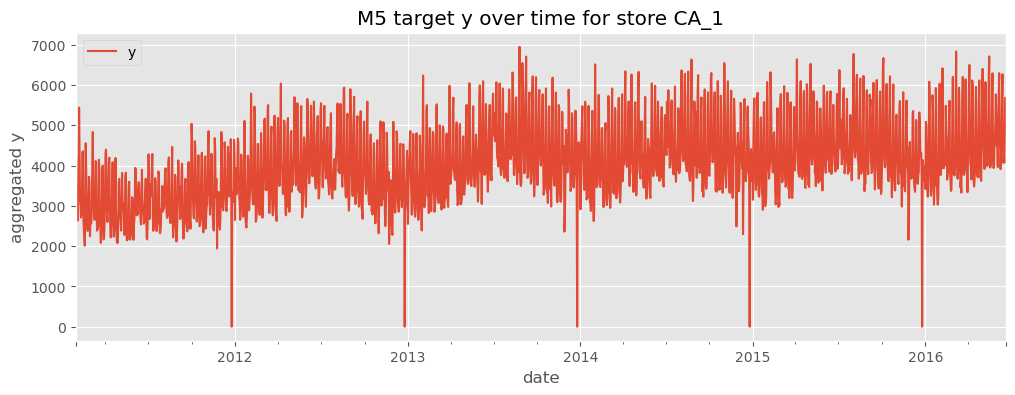

In [23]:
preview_store_id = 'CA_1'

preview_ids = S_df.loc[S_df['store_id'] == preview_store_id, 'unique_id']
preview_y = (
    Y_df[Y_df['unique_id'].isin(preview_ids)]
    .assign(ds=lambda df_: pd.to_datetime(df_['ds']))
    .groupby('ds', as_index=False)['y']
    .sum()
    .sort_values('ds')
)
ax = preview_y.plot(x='ds', y='y', figsize=(12, 4), title=f'M5 target y over time for store {preview_store_id}')
ax.set_xlabel('date')
ax.set_ylabel('aggregated y')
plt.show()


In [24]:
m5_cmp_params = {
    'store_ids': ['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3'],
    'dept_id': 'FOODS_1',
    'top_n_series': 64,
    'train_pct': 0.7,
    'n_rolling': 14,
    'batch_size': 32,
    'nf_batch_size': 32,
    'nf_windows_batch_size': 128,
    'nf_inference_windows_batch_size': 128,
    'torch_epochs': 40,
    'seed': 0,
    'nf_test_eval_steps': None,
    'nf_max_steps': 300,
}

m5_subset_results, m5_subset_meta = run_m5_subset_comparison(Y_df, X_df, S_df, m5_cmp_params)
display(m5_subset_results)


/var/folders/05/hxz2cbqj0js5tcp0f1bd23r40000gn/T/ipykernel_59036/2719649386.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subset_y.groupby('unique_id', as_index=False)['y']
/var/folders/05/hxz2cbqj0js5tcp0f1bd23r40000gn/T/ipykernel_59036/2719649386.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged['y'] = merged.groupby('unique_id', sort=False)['y'].diff()
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, whic

,model,train_corr_actual,test_corr_actual,train_mse_actual,test_mse_actual,train_mae_actual,test_mae_actual
0,TCTC,0.596085,0.522246,35.154015,45.750507,4.183308,4.773115
1,TFT,0.483872,0.440128,48.581177,51.408390,4.731289,4.777424
2,GlobalLSTM,0.231811,0.160088,50.734646,60.342182,4.778288,5.239641
3,VAR,0.998605,0.035568,0.153816,553.328918,0.248869,17.996515
4,TiDE,0.049057,0.025544,63.318439,63.501953,5.343376,5.350294
5,NBEATSx,0.061929,-0.023012,615.390442,16365.620117,5.283742,6.035404


## Sparse Attention Bootstrap

In [25]:
def keep_by_max_value(x, frac=0.1, min_keep=1):
    x = torch.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    positive = x > 0
    row_max = x.max(dim=-1, keepdim=True).values
    threshold = frac * row_max
    keep = positive & (x >= threshold)
    if min_keep and min_keep > 0:
        k = min(min_keep, x.shape[-1])
        _, idx = torch.topk(x, k=k, dim=-1, largest=True)
        topk_keep = torch.zeros_like(keep).scatter_(-1, idx, True)
        keep = keep | ((row_max > 0) & topk_keep)
    if x.shape[-1] == x.shape[-2]:
        eye = torch.eye(x.shape[-1], dtype=torch.bool, device=x.device)
        while eye.dim() < keep.dim():
            eye = eye.unsqueeze(0)
        keep = keep | ((row_max <= 0) & eye)
    return keep.to(x.dtype)


def make_sparse_bootstrap_model_builders(n_ts, n_f, n_rolling, mask_c, sparse_frac=0.1):
    common_kwargs = dict(
        nhead=1,
        dropout=TCTC_DROPOUT,
        d_model=n_ts * n_f,
        dim_feedforward=2 * n_ts * n_f,
        roll_y=True,
        embeddings='both',
    )
    return {
        'full_attention': lambda: models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC',
            sparsify=None,
            attn_normalizer='softmax',
            **common_kwargs,
        ).to(device),
        'max_sparse': lambda: models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC',
            sparsify=lambda attn: keep_by_max_value(attn, frac=sparse_frac),
            attn_normalizer='softmax',
            **common_kwargs,
        ).to(device),
        'entmax15': lambda: models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC',
            sparsify=None,
            attn_normalizer='entmax15',
            **common_kwargs,
        ).to(device),
    }


def _write_sparse_bootstrap_results(results, save_path):
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    df = pd.DataFrame(results).sort_values(['effect', 'rho', 'seed', 'model']).reset_index(drop=True)
    if save_path.suffix == '.parquet':
        df.to_parquet(save_path, index=False)
    else:
        df.to_csv(save_path, index=False)
    return df


def run_sparse_attention_bootstrap(
    effects=('TS_shift', 'CS_shift', 'TSCS_shift'),
    rhos=(0.005, 0.01, 0.03, 0.05),
    seeds=tuple(range(10)),
    T=4000,
    n_ts=SYNTH_N_TS,
    n_f=SYNTH_N_F,
    n_rolling=10,
    batch_size=256,
    epochs=100,
    shuffle_cs=False,
    sparse_frac=0.1,
    save_path='notebooks/results/sparse_bootstrap_results.csv',
    save_every=1,
    resume=True,
):
    mask_c = build_attention_mask(causal_mask, n_rolling, device=device)
    model_builders = make_sparse_bootstrap_model_builders(
        n_ts=n_ts,
        n_f=n_f,
        n_rolling=n_rolling,
        mask_c=mask_c,
        sparse_frac=sparse_frac,
    )

    completed = set()
    results = []
    save_path_obj = Path(save_path) if save_path else None
    if resume and save_path_obj is not None and save_path_obj.exists():
        if save_path_obj.suffix == '.parquet':
            existing = pd.read_parquet(save_path_obj)
        else:
            existing = pd.read_csv(save_path_obj)
        results = existing.to_dict('records')
        completed = {
            (row['effect'], float(row['rho']), int(row['seed']), row['model'])
            for row in results
        }
        print(f'Resuming sparse bootstrap from {save_path_obj} with {len(results)} saved rows.')

    unsaved_since_flush = 0

    run_specs = [
        (effect, rho, seed, model_name)
        for effect in effects
        for rho in rhos
        for seed in seeds
        for model_name in model_builders
    ]
    pending_specs = [spec for spec in run_specs if (spec[0], float(spec[1]), int(spec[2]), spec[3]) not in completed]

    progress = tqdm(pending_specs, desc='Sparse bootstrap', total=len(pending_specs))

    cached_dataset_key = None
    train_loader = None
    test_loader = None
    y_opt = None

    for effect, rho, seed, model_name in progress:
        dataset_key = (effect, float(rho), int(seed))
        if dataset_key != cached_dataset_key:
            np.random.seed(seed)
            torch.manual_seed(seed)
            X, y, y_opt, _ = generate_project_generator_dataset(
                effect=effect,
                T=T,
                n_ts=n_ts,
                n_f=n_f,
                rho=rho,
                random_ts_shift=1,
                seed=seed,
                shuffle_cs=shuffle_cs,
            )
            train_loader, test_loader = build_loaders_from_tensors(
                X, y,
                n_rolling=n_rolling,
                batch_size=batch_size,
                train_shuffle=False,
                test_shuffle=False,
                roll_y=True,
            )
            cached_dataset_key = dataset_key

        build_model = model_builders[model_name]
        progress.set_postfix(effect=effect, rho=f'{rho:.3f}', seed=seed, model=model_name)

        model = build_model()
        wrapper = torch_benchmarks.TorchWrapper(
            model,
            optimizer=make_tctc_optimizer(model),
            loss_fn=nn.MSELoss(),
            device=device,
        )
        wrapper.fit(
            train_loader,
            test_loader,
            epochs=epochs,
            plot=False,
            verbose=0,
            val_pct=TCTC_VAL_PCT,
            early_stopping_metric='corr',
            val_warmup_epochs=5,
        )
        results.append({
            'effect': effect,
            'rho': rho,
            'seed': seed,
            'model': model_name,
            'train_corr_optimal': corr_to_optimal(wrapper, train_loader, y_opt),
            'test_corr_optimal': corr_to_optimal(wrapper, test_loader, y_opt),
            'last_train_corr_noisy_y': wrapper.train_corr[-1] if wrapper.train_corr else None,
            'last_test_corr_noisy_y': wrapper.test_corr[-1] if wrapper.test_corr else None,
            'best_epoch': wrapper.best_epoch,
            'best_val_metric': wrapper.best_val_metric,
            'train_loss_finite': bool(np.isfinite(wrapper.train_loss).all()) if wrapper.train_loss else True,
            'test_loss_finite': bool(np.isfinite(wrapper.test_loss).all()) if wrapper.test_loss else True,
            'val_loss_finite': bool(np.isfinite(wrapper.val_loss).all()) if wrapper.val_loss else True,
        })
        completed.add((effect, float(rho), int(seed), model_name))
        unsaved_since_flush += 1

        if save_path_obj is not None and unsaved_since_flush >= save_every:
            _write_sparse_bootstrap_results(results, save_path_obj)
            unsaved_since_flush = 0
            print(f'Saved sparse bootstrap progress to {save_path_obj} ({len(results)} rows).')

    progress.close()

    if save_path_obj is not None:
        final_df = _write_sparse_bootstrap_results(results, save_path_obj)
        return final_df

    return pd.DataFrame(results).sort_values(['effect', 'rho', 'seed', 'model']).reset_index(drop=True)


def summarize_sparse_attention_bootstrap(df, metric='test_corr_optimal'):
    counts = df.groupby(['effect', 'rho', 'model'])[metric].size().rename('n')
    summary = (
        df.groupby(['effect', 'rho', 'model'])[metric]
          .agg(mean='mean', median='median', std='std')
          .reset_index()
          .merge(counts.reset_index(), on=['effect', 'rho', 'model'], how='left')
    )
    summary['sem'] = summary['std'] / np.sqrt(summary['n'])
    return summary.sort_values(['effect', 'rho', 'mean'], ascending=[True, True, False])


def display_sparse_attention_bootstrap(df, metric='test_corr_optimal'):
    return (
        df.groupby(['effect', 'rho', 'model'])[metric]
          .mean()
          .unstack('model')
          .style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1)
          .format(precision=3)
    )




In [30]:
def keep_by_max_value(x, frac=0.1, min_keep=1):
    x = torch.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    positive = x > 0
    row_max = x.max(dim=-1, keepdim=True).values
    threshold = frac * row_max
    keep = positive & (x >= threshold)
    if min_keep and min_keep > 0:
        k = min(min_keep, x.shape[-1])
        _, idx = torch.topk(x, k=k, dim=-1, largest=True)
        topk_keep = torch.zeros_like(keep).scatter_(-1, idx, True)
        keep = keep | ((row_max > 0) & topk_keep)
    if x.shape[-1] == x.shape[-2]:
        eye = torch.eye(x.shape[-1], dtype=torch.bool, device=x.device)
        while eye.dim() < keep.dim():
            eye = eye.unsqueeze(0)
        keep = keep | ((row_max <= 0) & eye)
    return keep.to(x.dtype)


def make_sparse_bootstrap_model_builders(n_ts, n_f, n_rolling, mask_c, sparse_frac=0.1):
    common_kwargs = dict(
        nhead=1,
        dropout=TCTC_DROPOUT,
        d_model=n_ts * n_f,
        dim_feedforward=2 * n_ts * n_f,
        roll_y=True,
        embeddings='both',
    )
    return {
        'full_attention': lambda: models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC',
            sparsify=None,
            attn_normalizer='softmax',
            **common_kwargs,
        ).to(device),
        'max_sparse': lambda: models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC',
            sparsify=lambda attn: keep_by_max_value(attn, frac=sparse_frac),
            attn_normalizer='softmax',
            **common_kwargs,
        ).to(device),
        # 'entmax15': lambda: models.CustomBiDimensionalTransformer(
        #     n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC',
        #     sparsify=None,
        #     attn_normalizer='entmax15',
        #     **common_kwargs,
        # ).to(device),
    }


def _write_sparse_bootstrap_results(results, save_path):
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    df = pd.DataFrame(results).sort_values(['effect', 'rho', 'seed', 'model']).reset_index(drop=True)
    if save_path.suffix == '.parquet':
        df.to_parquet(save_path, index=False)
    else:
        df.to_csv(save_path, index=False)
    return df


def run_sparse_attention_bootstrap(
    effects=('TS_shift', 'CS_shift', 'TSCS_shift'),
    rhos=(0.005, 0.01, 0.03, 0.05),
    seeds=tuple(range(10)),
    T=4000,
    n_ts=SYNTH_N_TS,
    n_f=SYNTH_N_F,
    n_rolling=10,
    batch_size=256,
    epochs=100,
    shuffle_cs=False,
    sparse_frac=0.1,
    save_path='notebooks/results/sparse_bootstrap_results2.csv',
    save_every=1,
    resume=True,
):
    mask_c = build_attention_mask(causal_mask, n_rolling, device=device)
    model_builders = make_sparse_bootstrap_model_builders(
        n_ts=n_ts,
        n_f=n_f,
        n_rolling=n_rolling,
        mask_c=mask_c,
        sparse_frac=sparse_frac,
    )

    completed = set()
    results = []
    save_path_obj = Path(save_path) if save_path else None
    if resume and save_path_obj is not None and save_path_obj.exists():
        if save_path_obj.suffix == '.parquet':
            existing = pd.read_parquet(save_path_obj)
        else:
            existing = pd.read_csv(save_path_obj)
        results = existing.to_dict('records')
        completed = {
            (row['effect'], float(row['rho']), int(row['seed']), row['model'])
            for row in results
        }
        print(f'Resuming sparse bootstrap from {save_path_obj} with {len(results)} saved rows.')

    unsaved_since_flush = 0

    run_specs = [
        (effect, rho, seed, model_name)
        for effect in effects
        for rho in rhos
        for seed in seeds
        for model_name in model_builders
    ]
    pending_specs = [spec for spec in run_specs if (spec[0], float(spec[1]), int(spec[2]), spec[3]) not in completed]

    progress = tqdm(pending_specs, desc='Sparse bootstrap', total=len(pending_specs))

    cached_dataset_key = None
    train_loader = None
    test_loader = None
    y_opt = None

    for effect, rho, seed, model_name in progress:
        dataset_key = (effect, float(rho), int(seed))
        if dataset_key != cached_dataset_key:
            np.random.seed(seed)
            torch.manual_seed(seed)
            X, y, y_opt, _ = generate_project_generator_dataset(
                effect=effect,
                T=T,
                n_ts=n_ts,
                n_f=n_f,
                rho=rho,
                random_ts_shift=1,
                seed=seed,
                shuffle_cs=shuffle_cs,
            )
            train_loader, test_loader = build_loaders_from_tensors(
                X, y,
                n_rolling=n_rolling,
                batch_size=batch_size,
                train_shuffle=False,
                test_shuffle=False,
                roll_y=True,
            )
            cached_dataset_key = dataset_key

        build_model = model_builders[model_name]
        progress.set_postfix(effect=effect, rho=f'{rho:.3f}', seed=seed, model=model_name)

        model = build_model()
        wrapper = torch_benchmarks.TorchWrapper(
            model,
            optimizer=make_tctc_optimizer(model),
            loss_fn=nn.MSELoss(),
            device=device,
        )
        wrapper.fit(
            train_loader,
            test_loader,
            epochs=epochs,
            plot=False,
            verbose=0,
            val_pct=None,
            early_stopping_metric=None,
            val_warmup_epochs=5,
        )
        results.append({
            'effect': effect,
            'rho': rho,
            'seed': seed,
            'model': model_name,
            'train_corr_optimal': corr_to_optimal(wrapper, train_loader, y_opt),
            'test_corr_optimal': corr_to_optimal(wrapper, test_loader, y_opt),
            'last_train_corr_noisy_y': wrapper.train_corr[-1] if wrapper.train_corr else None,
            'last_test_corr_noisy_y': wrapper.test_corr[-1] if wrapper.test_corr else None,
            'best_epoch': wrapper.best_epoch,
            'best_val_metric': wrapper.best_val_metric,
            'train_loss_finite': bool(np.isfinite(wrapper.train_loss).all()) if wrapper.train_loss else True,
            'test_loss_finite': bool(np.isfinite(wrapper.test_loss).all()) if wrapper.test_loss else True,
            'val_loss_finite': bool(np.isfinite(wrapper.val_loss).all()) if wrapper.val_loss else True,
        })
        completed.add((effect, float(rho), int(seed), model_name))
        unsaved_since_flush += 1

        if save_path_obj is not None and unsaved_since_flush >= save_every:
            _write_sparse_bootstrap_results(results, save_path_obj)
            unsaved_since_flush = 0

    progress.close()

    if save_path_obj is not None:
        final_df = _write_sparse_bootstrap_results(results, save_path_obj)
        return final_df

    return pd.DataFrame(results).sort_values(['effect', 'rho', 'seed', 'model']).reset_index(drop=True)


def summarize_sparse_attention_bootstrap(df, metric='test_corr_optimal'):
    counts = df.groupby(['effect', 'rho', 'model'])[metric].size().rename('n')
    summary = (
        df.groupby(['effect', 'rho', 'model'])[metric]
          .agg(mean='mean', median='median', std='std')
          .reset_index()
          .merge(counts.reset_index(), on=['effect', 'rho', 'model'], how='left')
    )
    summary['sem'] = summary['std'] / np.sqrt(summary['n'])
    return summary.sort_values(['effect', 'rho', 'mean'], ascending=[True, True, False])


def display_sparse_attention_bootstrap(df, metric='test_corr_optimal'):
    return (
        df.groupby(['effect', 'rho', 'model'])[metric]
          .mean()
          .unstack('model')
          .style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1)
          .format(precision=3)
    )




In [33]:
# Example bootstrap run for the sparse-attention comparison
sparse_bootstrap_results = run_sparse_attention_bootstrap(
    effects=('TS_shift', 'CS_shift'),
    rhos=[0.03, 0.04, 0.05, 0.02],
    seeds=tuple(range(30)),
    T=4000,
    n_ts=SYNTH_N_TS,
    n_f=SYNTH_N_F,
    n_rolling=10,
    batch_size=256,
    epochs=50,
    shuffle_cs=False,
    sparse_frac=0.1,
    save_path='notebooks/results/sparse_bootstrap_results2.csv',
    save_every=1,
    resume=True,
)

display(sparse_bootstrap_results.head())
display(summarize_sparse_attention_bootstrap(sparse_bootstrap_results, metric='test_corr_optimal'))
display(display_sparse_attention_bootstrap(sparse_bootstrap_results, metric='test_corr_optimal'))



Resuming sparse bootstrap from notebooks/results/sparse_bootstrap_results2.csv with 104 saved rows.


Sparse bootstrap:   0%|          | 1/376 [01:33<9:46:10, 93.79s/it, effect=TS_shift, model=max_sparse, rho=0.040, seed=22]    


KeyboardInterrupt: 

In [32]:
# Read saved sparse bootstrap results without rerunning the sweep
sparse_results_path = Path('notebooks/results/sparse_bootstrap_results2.csv')

if not sparse_results_path.exists():
    raise FileNotFoundError(f'No saved sparse bootstrap results found at {sparse_results_path}')

sparse_bootstrap_results_from_csv = pd.read_csv(sparse_results_path)

sparse_bootstrap_summary = summarize_sparse_attention_bootstrap(
    sparse_bootstrap_results_from_csv,
    metric='test_corr_optimal',
)

sparse_bootstrap_mean_table = (
    sparse_bootstrap_results_from_csv
    .groupby(['effect', 'rho', 'model'])['test_corr_optimal']
    .mean()
    .unstack('model')
    .sort_index()
)

sparse_bootstrap_count_table = (
    sparse_bootstrap_results_from_csv
    .groupby(['effect', 'rho', 'model'])['test_corr_optimal']
    .size()
    .unstack('model')
    .sort_index()
)

print(f'Loaded {len(sparse_bootstrap_results_from_csv)} rows from {sparse_results_path}')
display(
    sparse_bootstrap_summary
    .style
    .background_gradient(cmap='coolwarm', subset=['mean'], vmin=-1, vmax=1)
    .format({'rho': '{:.3f}', 'mean': '{:.3f}', 'median': '{:.3f}', 'std': '{:.3f}', 'sem': '{:.3f}'})
)
display(
    sparse_bootstrap_mean_table
    .style
    .background_gradient(cmap='coolwarm', vmin=-1, vmax=1)
    .format(precision=3)
)
display(
    sparse_bootstrap_count_table
    .style
    .background_gradient(cmap='Blues')
    .format(precision=0)
)


Loaded 104 rows from notebooks/results/sparse_bootstrap_results2.csv


,effect,rho,model,mean,median,std,n,sem
1,TS_shift,0.030,max_sparse,0.112,0.116,0.033,30,0.006
0,TS_shift,0.030,full_attention,0.111,0.115,0.042,30,0.008
2,TS_shift,0.040,full_attention,0.151,0.158,0.037,22,0.008
3,TS_shift,0.040,max_sparse,0.148,0.150,0.027,22,0.006
